# Fashion-MNIST classifier — CNN with PyTorch

Same dataset as the MLP version. Same 10 classes. But this time the model is a Convolutional Neural Network, and training is done with PyTorch (autograd handles backward, optimizer handles updates).

Goal: beat the MLP's 87.62% test accuracy.

Architecture mirrors the numpy CNN we built in `PRACTICE-ML/DeepLearning/CNN-byhand.py`:
```
input (1, 28, 28)
  -> conv1 (1->16, 3x3, pad=1) -> ReLU -> MaxPool 2x2  -> (16, 14, 14)
  -> conv2 (16->32, 3x3, pad=1) -> ReLU -> MaxPool 2x2 -> (32, 7, 7)
  -> flatten -> dense (1568->10) -> softmax (inside the loss)
```

In [1]:
                                                                                                                                                         
import sys           
!{sys.executable} -m pip install --upgrade --force-reinstall torch torchvision


Defaulting to user installation because normal site-packages is not writeable
  Using cached torch-2.12.0-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.27.0-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
Using cached torch-2.12.0-

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports + device setup

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

torch.manual_seed(42)

device: cpu
torch: 2.12.0+cpu


## 2. Load Fashion-MNIST (via torchvision)

`ToTensor()` converts the PIL image to a tensor of shape `(1, 28, 28)` with pixel values in `[0, 1]`. PyTorch's DataLoader handles shuffling and batching.

In [3]:
transform = transforms.ToTensor()

train_ds = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

print("train samples:", len(train_ds))
print("test samples: ", len(test_ds))

x_sample, y_sample = train_ds[0]
print("one image shape:", x_sample.shape, "label:", y_sample, "=", CLASS_NAMES[y_sample])

train samples: 60000
test samples:  10000
one image shape: torch.Size([1, 28, 28]) label: 9 = Ankle boot


## 3. Define the CNN

`nn.Module` is the base class. We declare layers in `__init__` and chain them in `forward()`. Backward is handled automatically by autograd.

Note: we do NOT apply softmax in `forward()`. `nn.CrossEntropyLoss` internally combines `log_softmax + NLLLoss`, so the model returns raw logits.

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc    = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        # x shape: (batch, 1, 28, 28)
        x = self.pool(F.relu(self.conv1(x)))   # -> (batch, 16, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))   # -> (batch, 32, 7, 7)
        x = x.view(x.size(0), -1)              # flatten: (batch, 1568)
        x = self.fc(x)                         # -> (batch, 10) logits
        return x


model = CNN().to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\ntotal parameters: {n_params:,}")

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)

total parameters: 20,490


## 4. Sanity-check the forward pass

Run one batch through the model. Output shape should be `(batch_size, 10)` — logits for each class.

In [5]:
x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)

logits = model(x_batch)
print("input shape: ", x_batch.shape)
print("output shape:", logits.shape)
print("sample logits (first image):", logits[0].detach().cpu().numpy().round(3))

input shape:  torch.Size([128, 1, 28, 28])
output shape: torch.Size([128, 10])
sample logits (first image): [-0.006 -0.011  0.15  -0.069 -0.071  0.074 -0.046  0.087 -0.117 -0.012]


## 5. Loss function + optimizer

Two pieces we need before training:

**Loss** — `nn.CrossEntropyLoss` does `log_softmax + NLL` in one step. That's why the model returns raw logits (no softmax in `forward`). In your numpy version you computed softmax yourself and then `-log(p[true_class])` — same math, fused for numerical stability.

**Optimizer** — `torch.optim.Adam` holds references to the model's parameters and updates them when we call `optimizer.step()`. In the numpy version you wrote the Adam update rule by hand (running `m`, `v`, bias correction, the `w -= lr * m_hat / (sqrt(v_hat) + eps)` line). Here PyTorch does all of that internally.

In [6]:
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("loss fn:  ", loss_fn)
print("optimizer:", optimizer)

loss fn:   CrossEntropyLoss()
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 6. Training loop (this is where backprop happens)

The five lines inside the inner loop are the whole story:

```python
logits = model(x)              # forward
loss   = loss_fn(logits, y)    # scalar loss
optimizer.zero_grad()          # clear old gradients
loss.backward()                # BACKPROP — autograd computes dL/dW for every parameter
optimizer.step()               # apply update rule (Adam in our case)
```

Mapping to your numpy CNN:

| PyTorch | numpy `CNN-byhand.py` equivalent |
| --- | --- |
| `loss.backward()` | the entire backward pass you wrote: `dL/dlogits` → unflatten → unpool → conv2 backward → unpool → conv1 backward |
| `optimizer.zero_grad()` | resetting `dW`, `db` to zero before each batch |
| `optimizer.step()` | your Adam update block (running `m`, `v`, bias correction, weight update) |

**Why `zero_grad()` matters:** PyTorch *accumulates* gradients into `.grad` by default (useful for things like gradient accumulation across mini-batches). If you don't zero them, batch 2's gradient gets added on top of batch 1's — your updates drift.

**How `loss.backward()` works under the hood:** every tensor operation in `forward()` was recorded in an autograd graph. `loss` is the root; `backward()` walks the graph in reverse, multiplying local Jacobians via chain rule, and deposits `dL/dparam` into each parameter's `.grad` attribute. That's literally the chain-rule machinery you wrote by hand — just automated.

In [7]:
EPOCHS = 5

train_losses = []
train_accs   = []

for epoch in range(1, EPOCHS + 1):
    model.train()                     # tells layers like dropout/batchnorm we're training (no-op here, good habit)
    running_loss = 0.0
    correct = 0
    total   = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)             # forward
        loss   = loss_fn(logits, y)   # scalar loss

        optimizer.zero_grad()         # wipe last batch's gradients
        loss.backward()               # BACKPROP — autograd fills every param's .grad
        optimizer.step()              # Adam update using those .grads

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"epoch {epoch}/{EPOCHS}  loss={epoch_loss:.4f}  acc={epoch_acc*100:.2f}%")

epoch 1/5  loss=0.5995  acc=78.75%
epoch 2/5  loss=0.3785  acc=86.52%
epoch 3/5  loss=0.3345  acc=88.07%
epoch 4/5  loss=0.3099  acc=88.97%
epoch 5/5  loss=0.2926  acc=89.59%


## 7. Evaluate on the test set

Two new things here:

- `model.eval()` — flips the model into inference mode (matters when you have dropout/batchnorm; harmless here but good habit).
- `torch.no_grad()` — disables autograd's graph tracking. We're not going to call `backward()`, so we don't need PyTorch to record the computation graph. Saves memory and runs faster.

Target: beat the MLP's **87.62%** test accuracy.

In [8]:
model.eval()
correct = 0
total   = 0
test_loss = 0.0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = loss_fn(logits, y)

        test_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)

test_loss /= total
test_acc   = correct / total

print(f"test loss: {test_loss:.4f}")
print(f"test acc : {test_acc*100:.2f}%")
print(f"MLP baseline was 87.62% — {'beaten ✓' if test_acc*100 > 87.62 else 'not beaten'}")

test loss: 0.3139
test acc : 88.68%
MLP baseline was 87.62% — beaten ✓


## 8. Training curves

Quick sanity plot — loss should be going down, accuracy should be going up. If the loss curve flattens early or the accuracy stalls, that's a hint to train longer, lower the learning rate, or add regularization.

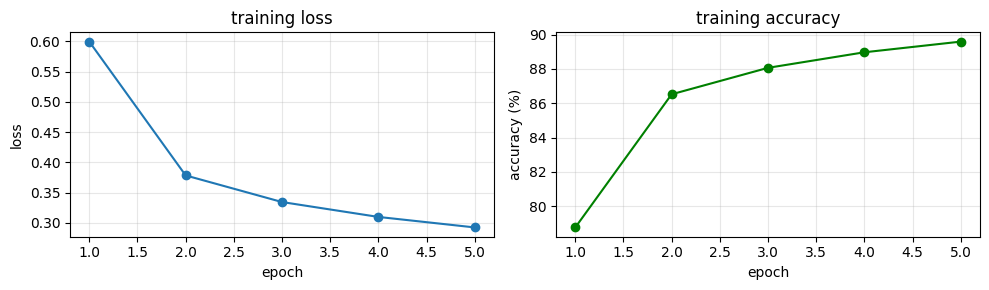

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(range(1, EPOCHS + 1), train_losses, marker='o')
axes[0].set_title("training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), [a * 100 for a in train_accs], marker='o', color='green')
axes[1].set_title("training accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Look at some predictions

Pick a batch from the test set and show what the model thinks. Green = correct, red = wrong. The wrong ones are usually the genuinely-confusing class pairs (Shirt vs T-shirt, Pullover vs Coat).

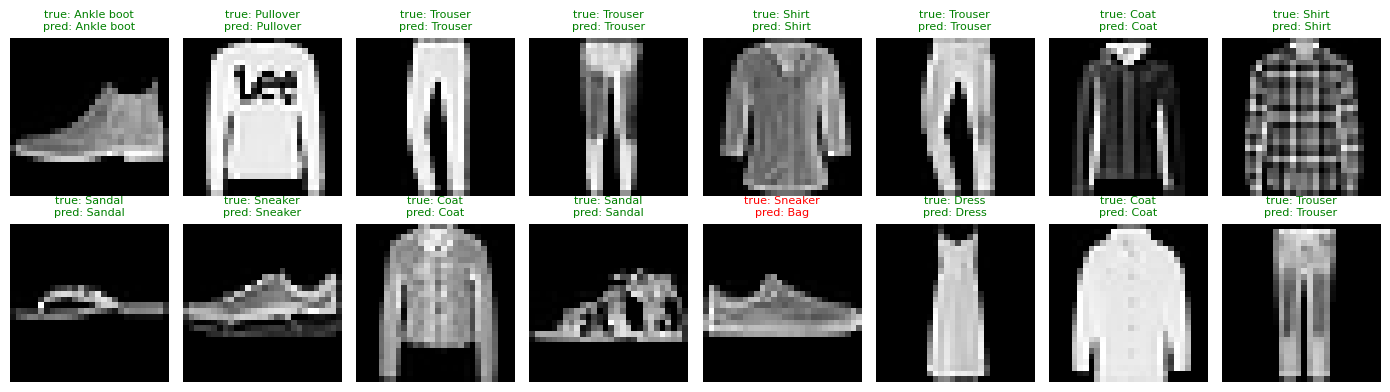

In [10]:
model.eval()
x_batch, y_batch = next(iter(test_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)

with torch.no_grad():
    preds = model(x_batch).argmax(dim=1)

n_show = 16
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img   = x_batch[i].cpu().squeeze().numpy()
    true  = CLASS_NAMES[y_batch[i].item()]
    pred  = CLASS_NAMES[preds[i].item()]
    color = "green" if true == pred else "red"

    ax.imshow(img, cmap="gray")
    ax.set_title(f"true: {true}\npred: {pred}", fontsize=8, color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()